# 02 · Análisis exploratorio (EDA) y estadístico

**Dataset:** `data/processed/hotel_bookings_wb.csv`, generado en `01_limpieza_union.ipynb`

**Preguntas de negocio:**
1. ¿Cómo se comportan la demanda y el precio (ADR) a lo largo del año?
2. ¿Qué factores están asociados a la cancelación?
3. ¿Qué canales y segmentos aportan más volumen y más valor?
4. ¿Influye el país de origen, y su nivel de renta, en el gasto?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
FIG = Path('../results/figures'); FIG.mkdir(parents=True, exist_ok=True)

def guardar(nombre):
    plt.tight_layout(); plt.savefig(FIG / f'{nombre}.png', dpi=120, bbox_inches='tight'); plt.show()

df = pd.read_csv('../data/processed/hotel_bookings_wb.csv',
                 parse_dates=['arrival_date', 'booking_date', 'reservation_status_date'])
MESES = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
         'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=MESES, ordered=True)
print(df.shape)
print('Periodo de llegadas:', df['arrival_date'].min().date(), '->', df['arrival_date'].max().date())

(87228, 52)
Periodo de llegadas: 2015-07-01 -> 2017-08-31


> **Nota:** el periodo no cubre años naturales completos. 2015 empieza en julio y 2017 termina en agosto, así que **no se comparan totales anuales directamente**. Para la estacionalidad se usa la media por mes o el año 2016, que es el único completo.

## 1. Análisis descriptivo
### 1.1 KPIs generales

In [2]:
no_cancel = df[df['is_canceled'] == 0]
kpis = pd.DataFrame({
    'Reservas': df.groupby('hotel').size(),
    'Tasa cancelación %': df.groupby('hotel')['is_canceled'].mean() * 100,
    'ADR medio': no_cancel.groupby('hotel')['adr'].mean(),
    'ADR mediano': no_cancel.groupby('hotel')['adr'].median(),
    'Estancia media (noches)': no_cancel.groupby('hotel')['total_nights'].mean(),
    'Antelación media (días)': df.groupby('hotel')['lead_time'].mean(),
    'Ingreso realizado': df.groupby('hotel')['revenue_realized'].sum(),
}).round(2)
kpis.loc['Total'] = [len(df), df['is_canceled'].mean()*100, no_cancel['adr'].mean(), no_cancel['adr'].median(),
                     no_cancel['total_nights'].mean(), df['lead_time'].mean(), df['revenue_realized'].sum()]
kpis.round(2)

,Reservas,Tasa cancelación %,ADR medio,ADR mediano,Estancia media (noches),Antelación media (días),Ingreso realizado
hotel,,,,,,,
City Hotel,53273.0,30.10,108.64,102.41,2.98,77.79,12150577.73
Resort Hotel,33955.0,23.48,93.00,74.25,4.20,83.38,10817034.22
Total,87228.0,27.52,102.22,94.89,3.48,79.97,22967611.95


### 1.2 Estadísticos de las variables numéricas

In [3]:
num = ['lead_time', 'adr', 'total_nights', 'total_guests', 'booking_changes',
       'days_in_waiting_list', 'total_of_special_requests', 'previous_cancellations']
desc = df[num].describe().T
desc['asimetría'] = df[num].skew(); desc['curtosis'] = df[num].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis
lead_time,87228.0,79.97,86.06,0.0,11.00,49.0,125.0,737.0,1.43,2.12
adr,87228.0,106.46,51.88,0.0,72.25,98.2,134.1,510.0,0.88,1.53
total_nights,87228.0,3.63,2.74,0.0,2.00,3.0,5.0,69.0,2.95,23.71
total_guests,87228.0,2.03,0.79,1.0,2.00,2.0,2.0,55.0,10.54,526.69
booking_changes,87228.0,0.27,0.71,0.0,0.00,0.0,0.0,18.0,5.07,54.00
days_in_waiting_list,87228.0,0.75,10.00,0.0,0.00,0.0,0.0,391.0,19.47,483.81
total_of_special_requests,87228.0,0.70,0.83,0.0,0.00,0.0,1.0,5.0,1.08,0.82
previous_cancellations,87228.0,0.03,0.37,0.0,0.00,0.0,0.0,26.0,34.33,1725.60


### 1.3 Distribución de variables categóricas

In [4]:
for col in ['hotel', 'market_segment', 'distribution_channel', 'customer_type', 'deposit_type', 'meal']:
    print(f'--- {col}'); print((df[col].value_counts(normalize=True) * 100).round(1).to_string(), '\n')

--- hotel
hotel
City Hotel      61.1
Resort Hotel    38.9 

--- market_segment
market_segment
Online TA        59.1
Offline TA/TO    15.9
Direct           13.5
Groups            5.6
Corporate         4.8
Complementary     0.8
Aviation          0.3
Unknown           0.0 

--- distribution_channel
distribution_channel
TA/TO        79.1
Direct       14.8
Corporate     5.8
GDS           0.2
Unknown       0.0 

--- customer_type


customer_type
Transient          82.4
Transient-Party    13.4
Contract            3.6
Group               0.6 

--- deposit_type
deposit_type
No Deposit    98.7
Non Refund     1.2
Refundable     0.1 

--- meal
meal
BB    77.8
SC    11.3
HB    10.4
FB     0.4 



### 1.4 Distribuciones de ADR, antelación y estancia

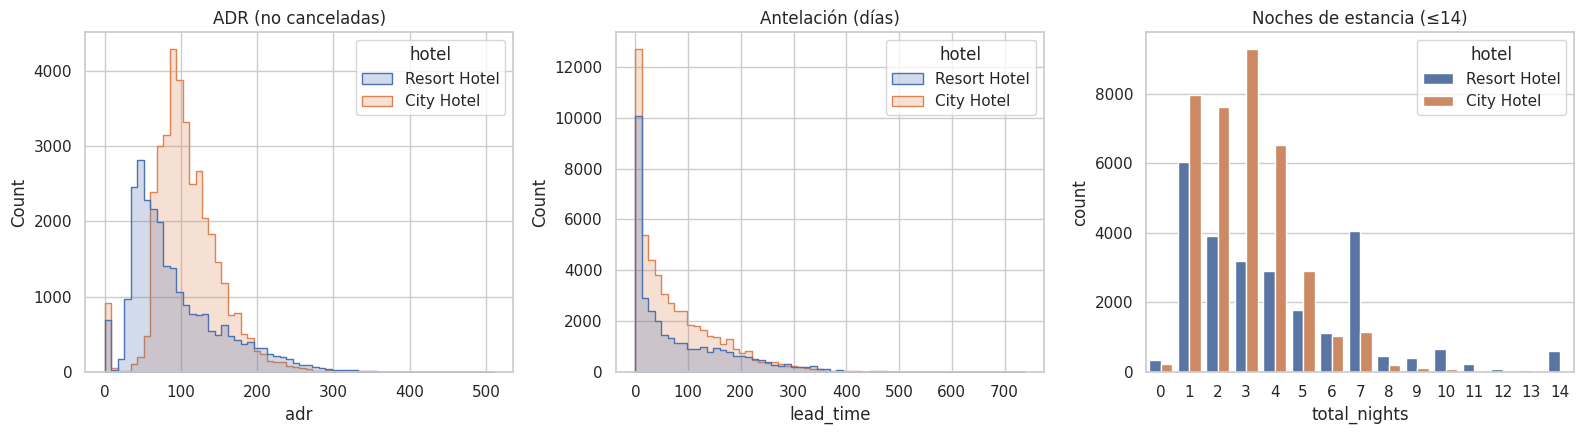

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(data=no_cancel, x='adr', hue='hotel', bins=60, element='step', ax=ax[0]); ax[0].set_title('ADR (no canceladas)')
sns.histplot(data=df, x='lead_time', hue='hotel', bins=60, element='step', ax=ax[1]); ax[1].set_title('Antelación (días)')
sns.countplot(data=no_cancel[no_cancel['total_nights'] <= 14], x='total_nights', hue='hotel', ax=ax[2]); ax[2].set_title('Noches de estancia (≤14)')
guardar('01_distribuciones')

## 2. Estacionalidad: demanda y precio

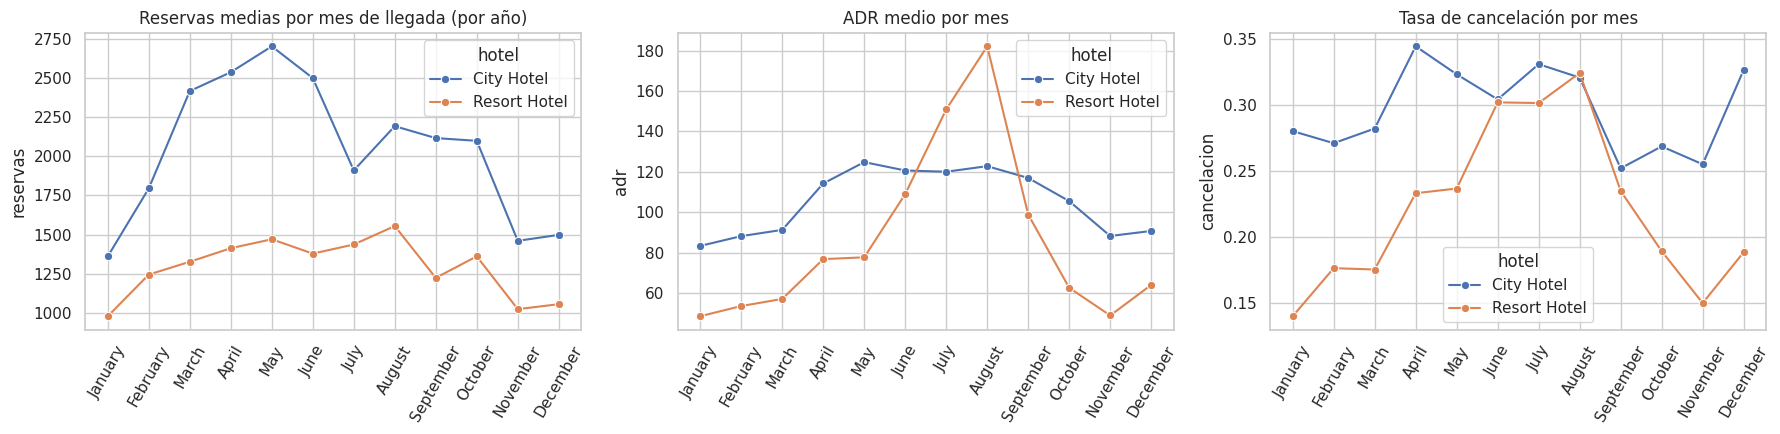

In [6]:
# Julio y agosto aparecen en 3 años y el resto en 2: se usa la media de reservas por año para no sesgar
mensual = (df.groupby(['hotel', 'arrival_date_month'], observed=True)
             .agg(reservas=('is_canceled', 'size'), cancelacion=('is_canceled', 'mean'),
                  años=('arrival_date_year', 'nunique'))
             .reset_index())
mensual['reservas'] = mensual['reservas'] / mensual['años']
adr_mes = no_cancel.groupby(['hotel', 'arrival_date_month'], observed=True)['adr'].mean().reset_index()

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.lineplot(data=mensual, x='arrival_date_month', y='reservas', hue='hotel', marker='o', ax=ax[0]); ax[0].set_title('Reservas medias por mes de llegada (por año)')
sns.lineplot(data=adr_mes, x='arrival_date_month', y='adr', hue='hotel', marker='o', ax=ax[1]); ax[1].set_title('ADR medio por mes')
sns.lineplot(data=mensual, x='arrival_date_month', y='cancelacion', hue='hotel', marker='o', ax=ax[2]); ax[2].set_title('Tasa de cancelación por mes')
for a in ax: a.tick_params(axis='x', rotation=60); a.set_xlabel('')
guardar('02_estacionalidad')

In [7]:
adr_mes.pivot(index='arrival_date_month', columns='hotel', values='adr').round(1)

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,83.4,48.6
February,88.2,53.6
March,91.3,57.1
April,114.3,76.8
May,124.8,77.7
June,120.7,109.0
July,120.1,150.9
August,122.8,182.1
September,117.0,98.9


## 3. Cancelaciones: ¿qué factores se asocian?

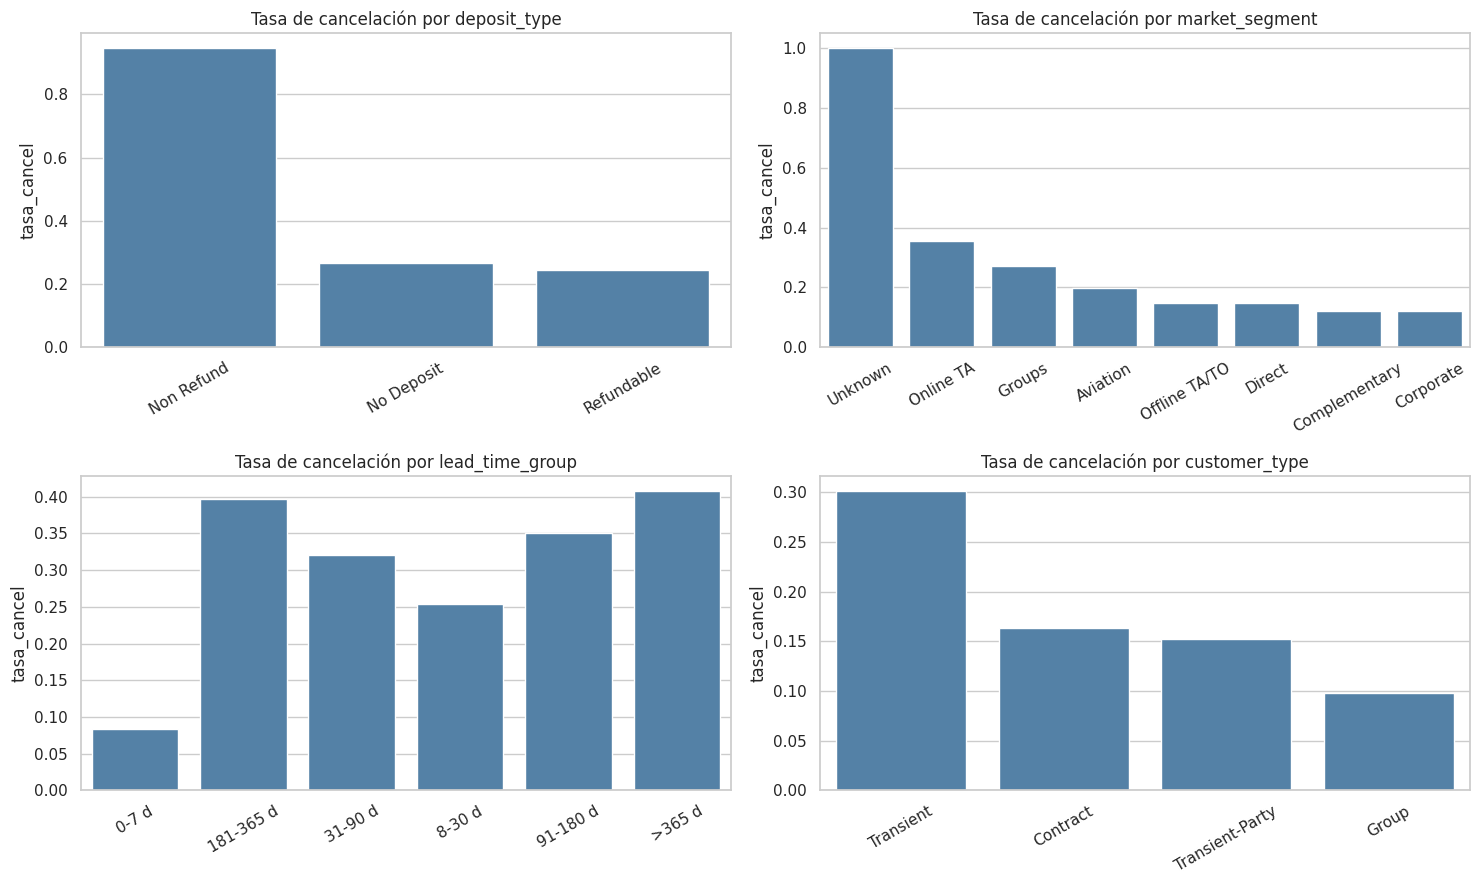

In [8]:
def tasa(col):
    return (df.groupby(col, observed=True)['is_canceled'].agg(['mean', 'size'])
              .rename(columns={'mean': 'tasa_cancel', 'size': 'reservas'})
              .sort_values('tasa_cancel', ascending=False))

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for a, col in zip(ax.flat, ['deposit_type', 'market_segment', 'lead_time_group', 'customer_type']):
    t = tasa(col).reset_index()
    if col == 'lead_time_group': t = t.sort_values(col)
    sns.barplot(data=t, x=col, y='tasa_cancel', ax=a, color='steelblue')
    a.set_title(f'Tasa de cancelación por {col}'); a.tick_params(axis='x', rotation=30); a.set_xlabel('')
guardar('03_cancelacion_factores')

In [9]:
for col in ['deposit_type', 'lead_time_group', 'is_repeated_guest', 'room_changed', 'has_company']:
    print(f'--- {col}'); print(tasa(col).round(3).to_string(), '\n')

--- deposit_type
              tasa_cancel  reservas
deposit_type                       
Non Refund          0.947      1037
No Deposit          0.267     86084
Refundable          0.243       107 

--- lead_time_group
                 tasa_cancel  reservas
lead_time_group                       
>365 d                 0.408       564
181-365 d              0.397     11192
91-180 d               0.350     18224
31-90 d                0.320     22719
8-30 d                 0.254     16326
0-7 d                  0.084     18203 

--- is_repeated_guest
                   tasa_cancel  reservas
is_repeated_guest                       
0                        0.283     83865
1                        0.077      3363 

--- room_changed
              tasa_cancel  reservas
room_changed                       
0                   0.315     74239
1                   0.047     12989 

--- has_company
             tasa_cancel  reservas
has_company                       
0                  0.286     8

## 4. Canales y segmentos: volumen vs valor

In [10]:
seg = (df.groupby('market_segment')
         .agg(reservas=('hotel', 'size'), tasa_cancel=('is_canceled', 'mean'),
              ingreso_realizado=('revenue_realized', 'sum'))
         .join(no_cancel.groupby('market_segment')['adr'].mean().rename('adr_medio'))
         .sort_values('ingreso_realizado', ascending=False))
seg['cuota_ingreso_%'] = seg['ingreso_realizado'] / seg['ingreso_realizado'].sum() * 100
seg.round(2)

,reservas,tasa_cancel,ingreso_realizado,adr_medio,cuota_ingreso_%
market_segment,,,,,
Online TA,51553,0.35,12966424.61,114.83,56.46
Offline TA/TO,13854,0.15,4595456.13,80.21,20.01
Direct,11780,0.15,3925328.52,115.07,17.09
Groups,4921,0.27,922900.97,74.76,4.02
Corporate,4200,0.12,483728.83,66.79,2.11
Aviation,226,0.20,68968.36,100.63,0.30
Complementary,692,0.12,4804.53,3.27,0.02
Unknown,2,1.00,0.00,NaN,0.00


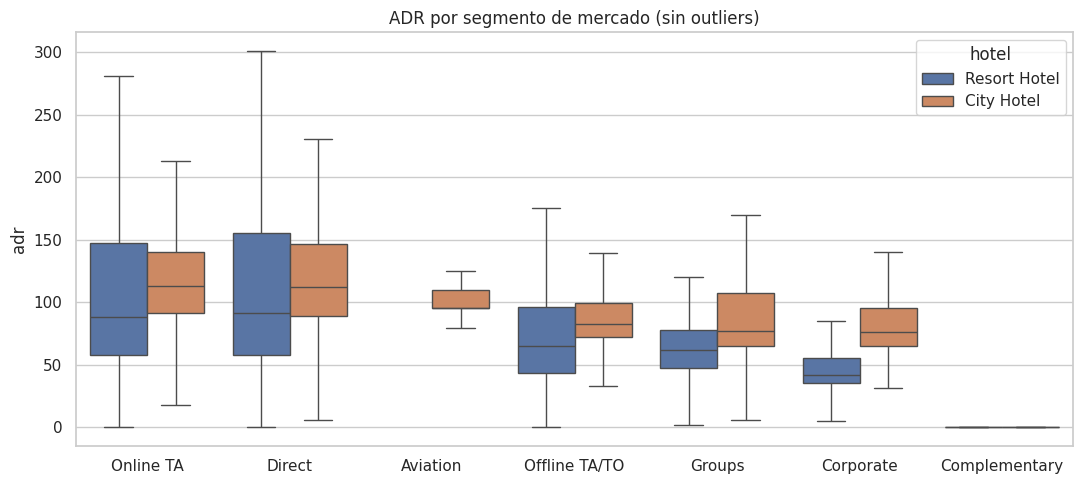

In [11]:
plt.figure(figsize=(11, 5))
orden = no_cancel.groupby('market_segment')['adr'].median().sort_values(ascending=False).index
sns.boxplot(data=no_cancel, x='market_segment', y='adr', hue='hotel', order=orden, showfliers=False)
plt.title('ADR por segmento de mercado (sin outliers)'); plt.xlabel('')
guardar('04_adr_segmento')

## 5. País de origen y contexto económico (Banco Mundial)

In [12]:
top = (df.groupby('country_name')
         .agg(reservas=('hotel', 'size'), tasa_cancel=('is_canceled', 'mean'))
         .join(no_cancel.groupby('country_name')['adr'].mean().rename('adr_medio'))
         .sort_values('reservas', ascending=False).head(10))
top.round(2)

,reservas,tasa_cancel,adr_medio
country_name,,,
Portugal,27354,0.36,91.92
United Kingdom,10423,0.19,91.88
France,8823,0.20,108.90
Spain,7244,0.26,116.01
Germany,5385,0.20,102.27
Italy,3061,0.35,113.00
Ireland,3015,0.22,96.13
Belgium,2081,0.20,112.95
Brazil,1993,0.36,109.81


In [13]:
orden_renta = ['High income', 'Upper middle income', 'Lower middle income', 'Low income', 'Sin datos']
renta = (df.groupby('income_group')
           .agg(reservas=('hotel', 'size'), tasa_cancel=('is_canceled', 'mean'))
           .join(no_cancel.groupby('income_group')['adr'].mean().rename('adr_medio'))
           .reindex([o for o in orden_renta if o in df['income_group'].unique()]))
renta.round(3)

,reservas,tasa_cancel,adr_medio
income_group,,,
High income,81505,0.269,102.076
Upper middle income,4160,0.370,109.551
Lower middle income,967,0.451,113.516
Low income,88,0.216,97.239
Sin datos,508,0.110,65.659


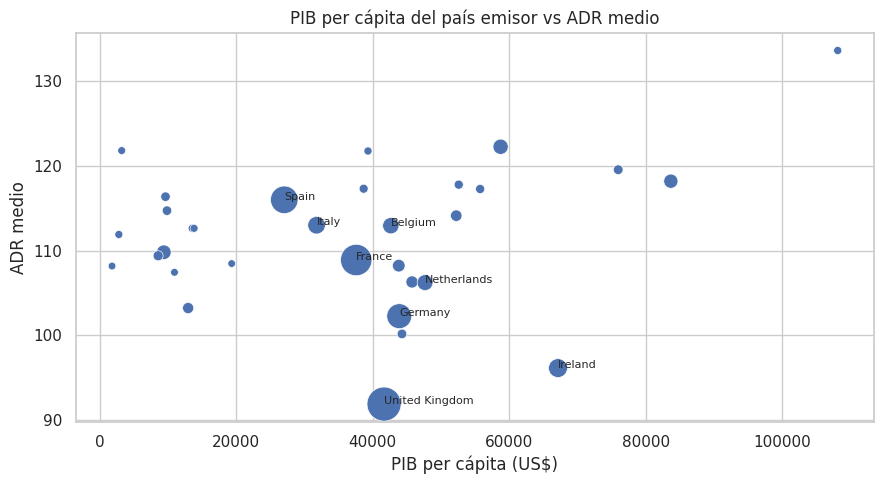

Países analizados: 32


In [14]:
# Nivel país: ¿los mercados con mayor PIB per cápita pagan más? (países con ≥100 reservas no canceladas, sin Portugal)
pais = (no_cancel[no_cancel['is_domestic'] == 0]
        .groupby('country_name')
        .agg(n=('adr', 'size'), adr=('adr', 'mean'), gdp=('gdp_per_capita_usd', 'mean'),
             lead=('lead_time', 'mean'), noches=('total_nights', 'mean'))
        .query('n >= 100').dropna())
plt.figure(figsize=(9, 5))
sns.scatterplot(data=pais, x='gdp', y='adr', size='n', sizes=(30, 600), legend=False)
for nombre, r in pais.nlargest(8, 'n').iterrows(): plt.annotate(nombre, (r['gdp'], r['adr']), fontsize=8)
plt.title('PIB per cápita del país emisor vs ADR medio'); plt.xlabel('PIB per cápita (US$)'); plt.ylabel('ADR medio')
guardar('05_gdp_vs_adr')
print(f'Países analizados: {len(pais)}')

## 6. Correlaciones

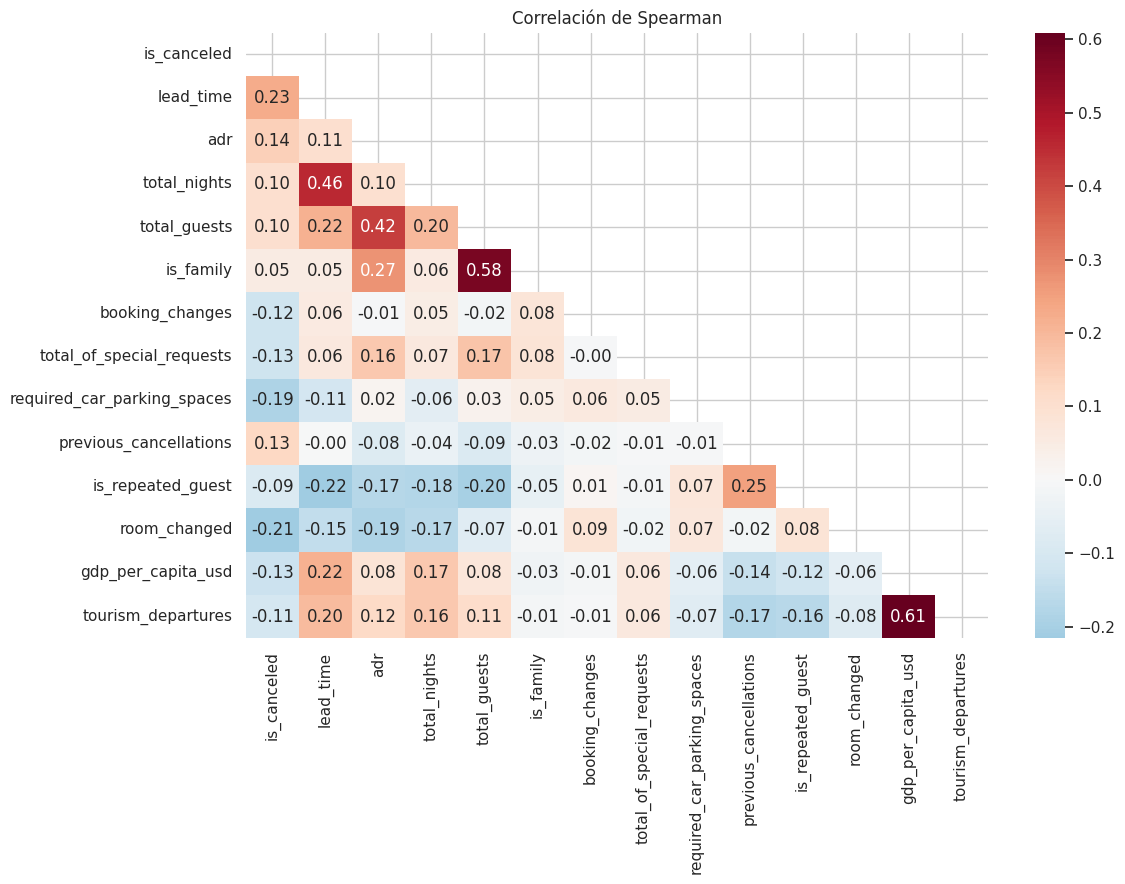

lead_time                      0.226
room_changed                  -0.213
required_car_parking_spaces   -0.186
adr                            0.142
gdp_per_capita_usd            -0.132
total_of_special_requests     -0.128
previous_cancellations         0.127
booking_changes               -0.124
tourism_departures            -0.108
total_nights                   0.104
total_guests                   0.101
is_repeated_guest             -0.089
is_family                      0.051
Name: is_canceled, dtype: float64

In [15]:
cols = ['is_canceled', 'lead_time', 'adr', 'total_nights', 'total_guests', 'is_family', 'booking_changes',
        'total_of_special_requests', 'required_car_parking_spaces', 'previous_cancellations',
        'is_repeated_guest', 'room_changed', 'gdp_per_capita_usd', 'tourism_departures']
corr = df[cols].corr(method='spearman')
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, mask=np.triu(np.ones_like(corr, bool)))
plt.title('Correlación de Spearman')
guardar('06_correlaciones')
corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False).round(3)

## 7. Análisis estadístico (contrastes de hipótesis)

Nivel de significación α = 0,05. Con muestras de este tamaño casi cualquier diferencia sale significativa, así que **se reporta también el tamaño del efecto** (V de Cramér, r de rango biserial, ε²) para valorar su relevancia práctica.

### 7.1 ¿El ADR sigue una distribución normal?

D'Agostino-Pearson: estadístico=8793.7, p=0.00e+00


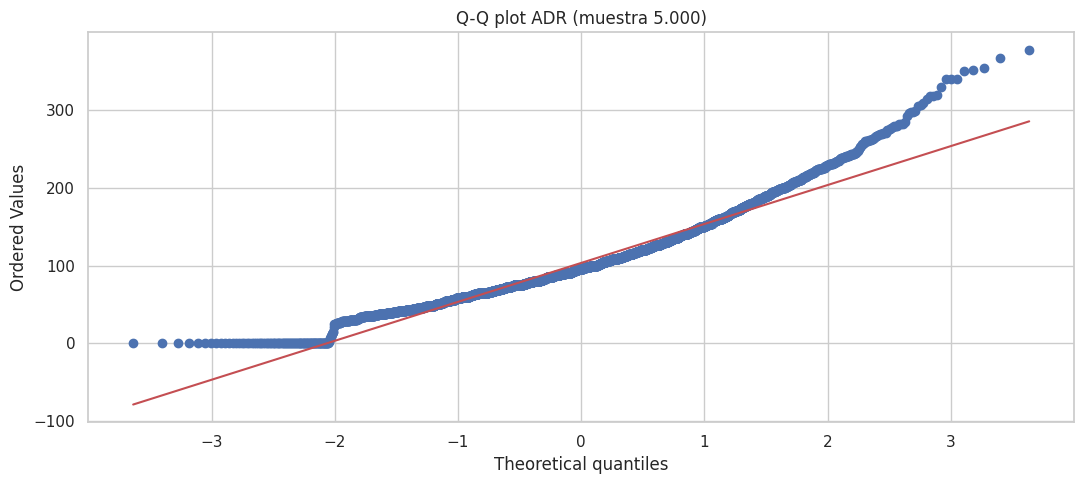

-> No normal: se usan contrastes no paramétricos (Mann-Whitney, Kruskal-Wallis, Spearman).


In [16]:
muestra = no_cancel['adr'].sample(5000, random_state=42)
stat, p = stats.normaltest(no_cancel['adr'])
print(f"D'Agostino-Pearson: estadístico={stat:.1f}, p={p:.2e}")
stats.probplot(muestra, dist='norm', plot=plt); plt.title('Q-Q plot ADR (muestra 5.000)')
guardar('07_qqplot_adr')
print('-> No normal: se usan contrastes no paramétricos (Mann-Whitney, Kruskal-Wallis, Spearman).')

### 7.2 Cancelación vs variables categóricas (χ² de independencia + V de Cramér)

In [17]:
def chi2_cramer(col):
    tabla = pd.crosstab(df[col], df['is_canceled'])
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    v = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))
    return {'variable': col, 'chi2': round(chi2, 1), 'gl': dof, 'p_valor': p, 'V_Cramer': round(v, 3)}

res_chi = pd.DataFrame([chi2_cramer(c) for c in
    ['hotel', 'deposit_type', 'market_segment', 'distribution_channel', 'customer_type',
     'lead_time_group', 'is_repeated_guest', 'room_changed', 'income_group', 'season']]).sort_values('V_Cramer', ascending=False)
res_chi

,variable,chi2,gl,p_valor,V_Cramer
5,lead_time_group,4993.0,5,0.000000e+00,0.239
2,market_segment,4271.2,7,0.000000e+00,0.221
7,room_changed,3969.1,1,0.000000e+00,0.213
1,deposit_type,2374.2,2,0.000000e+00,0.165
3,distribution_channel,2027.2,4,0.000000e+00,0.152
4,customer_type,1411.7,3,8.557488e-306,0.127
6,is_repeated_guest,685.9,1,3.558364e-151,0.089
9,season,500.8,3,3.159484e-108,0.076
0,hotel,454.4,1,7.952968e-101,0.072
8,income_group,423.4,4,2.409776e-90,0.070


### 7.3 ADR: City Hotel vs Resort Hotel (Mann-Whitney U)
H₀: la distribución del ADR es la misma en ambos hoteles.

In [18]:
city = no_cancel.loc[no_cancel['hotel'] == 'City Hotel', 'adr']
resort = no_cancel.loc[no_cancel['hotel'] == 'Resort Hotel', 'adr']
u, p = stats.mannwhitneyu(city, resort, alternative='two-sided')
r_rb = 2 * u / (len(city) * len(resort)) - 1   # >0: City mayor que Resort
print(f'Mediana City={city.median():.1f} | Resort={resort.median():.1f}')
print(f'U={u:,.0f}, p={p:.2e}, r rango-biserial={r_rb:.3f}')

Mediana City=102.4 | Resort=74.2
U=629,587,656, p=0.00e+00, r rango-biserial=0.301


### 7.4 ADR por segmento de mercado (Kruskal-Wallis)
H₀: el ADR mediano es igual en todos los segmentos.

In [19]:
grupos = [g['adr'].values for _, g in no_cancel.groupby('market_segment') if len(g) > 30]
h, p = stats.kruskal(*grupos)
n = sum(len(g) for g in grupos); eps2 = (h - len(grupos) + 1) / (n - len(grupos))
print(f'H={h:,.1f}, p={p:.2e}, ε²={eps2:.3f}')

H=11,037.9, p=0.00e+00, ε²=0.175


### 7.5 Antelación: canceladas vs no canceladas (Mann-Whitney U)

In [20]:
canc = df.loc[df['is_canceled'] == 1, 'lead_time']; ok = df.loc[df['is_canceled'] == 0, 'lead_time']
u, p = stats.mannwhitneyu(canc, ok, alternative='greater')
r_rb = 2 * u / (len(canc) * len(ok)) - 1
print(f'Mediana canceladas={canc.median():.0f} d | no canceladas={ok.median():.0f} d')
print(f'U={u:,.0f}, p={p:.2e}, r rango-biserial={r_rb:.3f}')

Mediana canceladas=80 d | no canceladas=38 d
U=980,701,206, p=0.00e+00, r rango-biserial=0.292


### 7.6 PIB per cápita del país emisor vs ADR (Spearman, nivel país)

In [21]:
rho, p = stats.spearmanr(pais['gdp'], pais['adr'])
print(f'Países={len(pais)} | rho={rho:.3f}, p={p:.3f}')
for var in ['lead', 'noches']:
    r, pv = stats.spearmanr(pais['gdp'], pais[var]); print(f'PIB vs {var}: rho={r:.3f}, p={pv:.3f}')

Países=32 | rho=0.184, p=0.313
PIB vs lead: rho=0.639, p=0.000
PIB vs noches: rho=0.257, p=0.156


## 8. Resumen de hallazgos

**Estacionalidad y precio**
- El **Resort** tiene una estacionalidad muy marcada: su ADR medio pasa de unos 49 en enero y noviembre a unos 182 en agosto. El **City** es mucho más estable, entre 83 y 125, con picos en primavera.
- El ADR mediano del City (102) supera al del Resort (74). La diferencia es significativa (Mann-Whitney, p < 0,001) con un efecto moderado.

**Cancelaciones (27,5 % global; City 30,1 % y Resort 23,5 %)**
- La **antelación** es el factor más asociado (V de Cramér = 0,24). Se cancela el 8 % de las reservas con 0-7 días de antelación frente a casi el 40 % de las que tienen más de 180 días. La mediana de antelación es de 80 días en las canceladas y de 38 en las no canceladas.
- El **segmento** también pesa mucho (V = 0,22): Online TA cancela el 35 %, mientras que Direct y Offline TA/TO cancelan el 15 %.
- Los **clientes repetidores** cancelan el 8 %, frente al 28 % del resto.
- **Anomalía:** las reservas *Non Refund* cancelan el 95 %. Es contraintuitivo y apunta a cómo registra el hotel estas reservas (por ejemplo, cancelaciones por impago), no a un comportamiento del cliente.
- **Precaución:** `room_changed` muestra una asociación fuerte, pero es una variable *a posteriori*, porque la habitación se asigna en el check-in. No sirve para predecir cancelaciones.

**Canales**
- **Online TA** genera el 59 % de las reservas y el 56 % del ingreso realizado, con ADR alto (115), pero también la mayor cancelación.
- **Direct** tiene un ADR similar (115) con menos de la mitad de cancelaciones: es el canal más rentable por reserva.
- El segmento explica una parte relevante de la variación del ADR (Kruskal-Wallis, ε² = 0,18).

**País de origen y contexto económico**
- Portugal (mercado doméstico) aporta el 31 % de las reservas y cancela el 36 %, por encima de los mercados emisores europeos, que están en torno al 18-20 %.
- A nivel país, **el PIB per cápita no se correlaciona con el ADR** (Spearman ρ = 0,18, p = 0,31, 32 países). Sí se correlaciona con la **antelación** (ρ = 0,64, p < 0,001): los mercados más ricos reservan con más tiempo.